In [ ]:
Assignment: Employee Attrition Prediction using Artificial Neural Networks (ANN)

Objective

Build an Artificial Neural Network (ANN) model that predicts whether an
employee is likely to leave a company based on their personal and
professional information.

Business Problem

Employee attrition is a major challenge for organizations. High
attrition leads to increased hiring costs, loss of productivity, and
reduced team stability. As an AI Engineer, your task is to build a
predictive model that helps the HR department identify employees who are
at risk of leaving the organization.

Dataset

Use the IBM HR Analytics Employee Attrition & Performance dataset from
Kaggle.

Target Variable: - Attrition (Yes/No)

Tasks

1.  Load and explore the dataset.
2.  Perform data cleaning.
3.  Handle missing values (if any).
4.  Encode categorical variables.
5.  Perform feature scaling where required.
6.  Split the dataset into training and testing sets.
7.  Build an ANN using TensorFlow/Keras.
8.  Experiment with:
    -   Number of hidden layers
    -   Number of neurons
    -   Activation functions
    -   Batch size
    -   Number of epochs
9.  Apply at least one regularization technique such as Dropout or Early
    Stopping.
10. Evaluate your model using:
    -   Accuracy
    -   Precision
    -   Recall
    -   F1-Score
    -   Confusion Matrix
11. Compare training and validation performance.
12. Write a short conclusion discussing your results and possible
    improvements.

Bonus (Optional)

-   Compare ANN with Logistic Regression or Random Forest.
-   Build a simple Streamlit application for prediction.
-   Explain predictions using SHAP.

Deliverables

Submit the following: - Python Notebook (.ipynb) - Source Code - Trained
Model - Project Report (2–3 pages) - GitHub Repository Link (Optional)

Submission Guidelines

-   Write clean, well-commented code.
-   Use meaningful variable names.
-   Include visualizations wherever appropriate.
-   Ensure the notebook runs without errors.

All the best!

In [4]:
import pandas as pd

In [2]:
import numpy as np

In [5]:
import matplotlib.pyplot as plt

In [6]:
import seaborn as sns

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [10]:
import tensorflow as tf

In [11]:
from tensorflow.keras.models import Sequential

In [12]:
from tensorflow.keras.layers import Dense,Dropout

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
sns.set(style="whitegrid")

In [15]:
# 3 – Load dataset

df=pd.read_csv("Employeeattrition.csv")# make sure this file is in the same folder as your notebook
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

(1470, 35)

In [16]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [17]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [18]:
df["Attrition"]

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object

In [19]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [20]:
# 4)  DATA CLEANING - Tells you how many missing values or null values there in each column
# check missing values
missing=df.isnull().sum()

In [21]:
print(missing)

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [56]:
#5) handle missing values
# as there are 0 no missing values as shown above so there is no need to drop rows for missing data. 

In [23]:
print([missing>0]) 
print("All columns have zero missing values:\n", df.isnull().sum()) # for clarity if there are any missing values or not

[Age                         False
Attrition                   False
BusinessTravel              False
DailyRate                   False
Department                  False
DistanceFromHome            False
Education                   False
EducationField              False
EmployeeCount               False
EmployeeNumber              False
EnvironmentSatisfaction     False
Gender                      False
HourlyRate                  False
JobInvolvement              False
JobLevel                    False
JobRole                     False
JobSatisfaction             False
MaritalStatus               False
MonthlyIncome               False
MonthlyRate                 False
NumCompaniesWorked          False
Over18                      False
OverTime                    False
PercentSalaryHike           False
PerformanceRating           False
RelationshipSatisfaction    False
StandardHours               False
StockOptionLevel            False
TotalWorkingYears           False
TrainingTimes

In [24]:
#6) Encoding categorical variables

In [25]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [26]:
df['Attrition']=df["Attrition"].map({"Yes":1,"No":0}) #encoding attrition target

In [27]:
#Encoding is done above why it is needed because machine learning models work with numbers, not text categories.

In [28]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [ ]:
# Separate categorical and numerical columns

In [29]:
categorical_cols=df.select_dtypes(include=['object']).columns.tolist()

In [30]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [31]:
print("Categorical coloumns to encode:",categorical_cols)

Categorical coloumns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [32]:
categorical_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [33]:
numerical_cols=df.select_dtypes(include=['float','int']).columns.tolist()

In [34]:
numerical_cols

['Age',
 'Attrition',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EmployeeCount',
 'EmployeeNumber',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StandardHours',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [ ]:
# One-hot encode categorical features (drop_first to avoid dummy trap)
# Encoding is needed because machine learning models work with numbers, not text categories.

In [35]:
df_encoded = pd.get_dummies(df,columns=categorical_cols,drop_first=True)
print("shape after encoding:",df_encoded.shape)

shape after encoding: (1470, 48)


In [36]:
categorical_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [ ]:
# Performing feature scaling 

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [38]:
X= df_encoded.drop("Attrition",axis=1)
y=df_encoded["Attrition"]

#X means all columns except Attrition.
#y means only the Attrition column.
#Example:Age, MonthlyIncome, JobRole, etc. go into X and Attrition goes into y

In [39]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [40]:
numeric_cols = [c for c in X.columns if X[c].dtype in ['int64', 'float64']]

#This creates a list of only numeric columns.
#Examples: Age, DailyRate, MonthlyIncome, YearsAtCompany
#We do this because only numeric columns need scaling.

In [41]:
scaler = StandardScaler()

In [42]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

#These copies are made so the original data is not changed.
#You will replace only the numeric columns with scaled values.

In [43]:
#Scale training numeric columns
X_train_scaled[numeric_cols]=scaler.fit_transform(X_train[numeric_cols])

#fit_transform() does 2 things:
#fit = learns mean and standard deviation from training
#data transform = applies scaling
#This is done only on training data to avoid leakage.

In [44]:
#Scale testing numeric columns
X_test_scaled[numeric_cols]=scaler.transform(X_test[numeric_cols])

In [45]:
import tensorflow as tf

In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [47]:
# ------------------------------
# Build and compile the ANN model for employee attrition
# ------------------------------

# Number of input features (columns) after scaling
input_dim = X_train_scaled.shape[1]

# Define the ANN model using Sequential API
model = Sequential([
    Dense(64, activation="relu", input_shape=(input_dim,)),  # first hidden layer
    Dense(32, activation="relu"),                            # second hidden layer
    Dense(1, activation="sigmoid")                           # output layer (binary classification)
])

# Compile the model with appropriate loss and metric
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Display model architecture
model.summary()

C:\Users\J Shiva Goud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,185 (20.25 KB)

 Trainable params: 5,185 (20.25 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# Train the ANN model on the scaled training data
# epochs: number of times the model sees the entire training data
# batch_size: number of samples before updating weights
# validation_split: fraction of training data used for validation

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=50,          # you will experiment with this
    batch_size=32,      # you will experiment with this too
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8277 - loss: 0.4692 - val_accuracy: 0.8305 - val_loss: 0.4183
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8404 - loss: 0.3924 - val_accuracy: 0.8347 - val_loss: 0.3865
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8468 - loss: 0.3636 - val_accuracy: 0.8432 - val_loss: 0.3675
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8585 - loss: 0.3388 - val_accuracy: 0.8686 - val_loss: 0.3544
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8734 - loss: 0.3164 - val_accuracy: 0.8729 - val_loss: 0.3441
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8862 - loss: 0.2926 - val_accuracy: 0.8729 - val_loss: 0.3354
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9021 - loss: 0.2745 - val_accuracy: 0.8729 - val_loss: 0.3314
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9011 - loss: 0.2579 - val_accuracy: 0.8644 - val_loss

In [49]:
# ------------------------------
# Evaluate model on test data
# ------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Get predicted probabilities and convert to class labels (0/1)
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred)
test_recall = recall_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)
test_cm = confusion_matrix(y_test, y_pred)

print("Test Accuracy :", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall   :", test_recall)
print("Test F1-Score :", test_f1)
print("Confusion Matrix:\n", test_cm)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Test Accuracy : 0.8367346938775511
Test Precision: 0.4864864864864865
Test Recall   : 0.3829787234042553
Test F1-Score : 0.42857142857142855
Confusion Matrix:
 [[228  19]
 [ 29  18]]


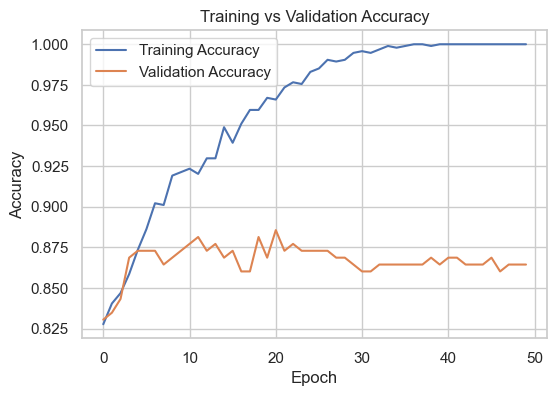

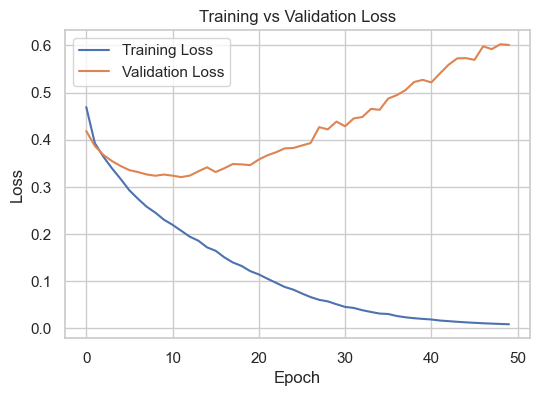

In [50]:
# ------------------------------
# Plot training vs validation accuracy and loss
# ------------------------------
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(6,4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

# Loss plot
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [51]:
# ------------------------------
# Build a regularized model with Dropout and EarlyStopping
# ------------------------------
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_scaled.shape[1]

model_reg = Sequential([
    Dense(128, activation="relu", input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_reg.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_reg = model_reg.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


C:\Users\J Shiva Goud\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8043 - loss: 0.4976 - val_accuracy: 0.8305 - val_loss: 0.4113
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8404 - loss: 0.4127 - val_accuracy: 0.8347 - val_loss: 0.3750
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8468 - loss: 0.3839 - val_accuracy: 0.8475 - val_loss: 0.3552
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8511 - loss: 0.3663 - val_accuracy: 0.8559 - val_loss: 0.3365
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8734 - loss: 0.3453 - val_accuracy: 0.8602 - val_loss: 0.3291
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8798 - loss: 0.3285 - val_accuracy: 0.8517 - val_loss: 0.3288
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8809 - loss: 0.3090 - val_accuracy: 0.8771 - val_loss: 0.3146
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8851 - loss: 0.3137 - val_accuracy: 0.8559 - val_loss: 0.

In [52]:
# ------------------------------
# Evaluate regularized model on test data
# ------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

y_pred_proba_reg = model_reg.predict(X_test_scaled)
y_pred_reg = (y_pred_proba_reg >= 0.5).astype(int).ravel()

test_accuracy_reg = accuracy_score(y_test, y_pred_reg)
test_precision_reg = precision_score(y_test, y_pred_reg)
test_recall_reg = recall_score(y_test, y_pred_reg)
test_f1_reg = f1_score(y_test, y_pred_reg)
test_cm_reg = confusion_matrix(y_test, y_pred_reg)

print("Regularized Model Test Accuracy :", test_accuracy_reg)
print("Regularized Model Test Precision:", test_precision_reg)
print("Regularized Model Test Recall   :", test_recall_reg)
print("Regularized Model Test F1-Score :", test_f1_reg)
print("Regularized Model Confusion Matrix:\n", test_cm_reg)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Regularized Model Test Accuracy : 0.8639455782312925
Regularized Model Test Precision: 0.6296296296296297
Regularized Model Test Recall   : 0.3617021276595745
Regularized Model Test F1-Score : 0.4594594594594595
Regularized Model Confusion Matrix:
 [[237  10]
 [ 30  17]]


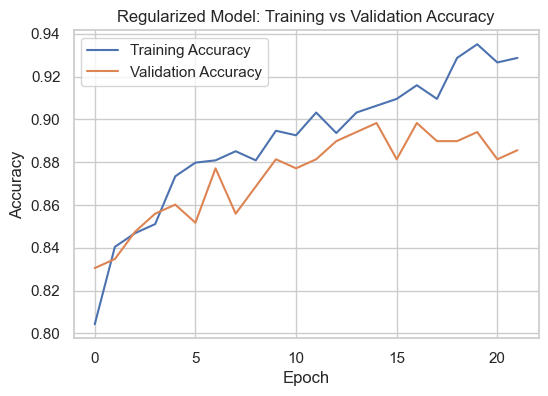

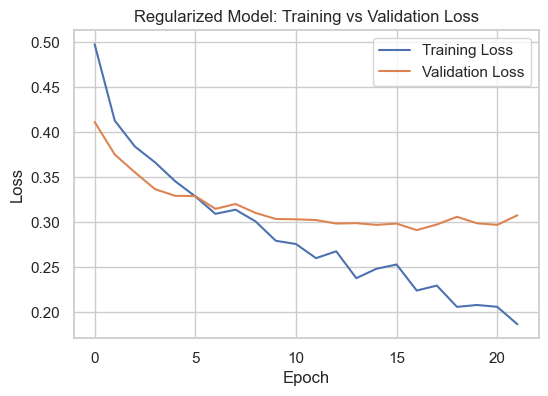

In [53]:
# ------------------------------
# Plot training vs validation accuracy and loss for regularized model
# ------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_reg.history["accuracy"], label="Training Accuracy")
plt.plot(history_reg.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularized Model: Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_reg.history["loss"], label="Training Loss")
plt.plot(history_reg.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularized Model: Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
| Model           | Accuracy | Precision | Recall | F1-Score |
|-----------------|----------|-----------|--------|----------|
| Baseline ANN    | 0.837    | 0.486     | 0.383  | 0.429    |
| Regularized ANN | 0.864    | 0.630     | 0.362  | 0.459    |

In [57]:
# Save the best model (regularized) in the native Keras format
model_reg.save("employee_attrition_ann_model.keras")

In [ ]:
                                                        #Conclusion
An Artificial Neural Network was developed to predict employee attrition using the IBM HR Analytics dataset.
The baseline ANN, with two hidden layers (64 and 32 neurons) and ReLU activation, achieved test accuracy of
0.837, precision of 0.486, recall of 0.383, and F1‑score of 0.429. The training accuracy reached nearly 1.00
while validation accuracy remained around 0.86, indicating overfitting.

A regularized model with Dropout layers and EarlyStopping was then built to improve generalization.
This model achieved higher test accuracy (0.864), precision (0.630), and F1‑score (0.459),while 
reducing the number of false positives in the confusion matrix. However, recall for the attrition
class remained low (0.362), meaning the model still misses many employees who actually leave.

Overall, the regularized model outperforms the baseline in accuracy and precision, and the use of 
Dropout and EarlyStopping effectively controls overfitting. Future improvements could include 
stronger handling of class imbalance (e.g., class weights or SMOTE), more extensive hyperparameter
tuning, and comparison with other models such as Logistic Regression, Random Forest, or Gradient Boosting
to further improve recall for the attrition class.